# Justinnn

In [2]:
change_cols = change_feature_cols=[  # specify the change feature columns
    "tech_investment_ratio_change",
    "nib_deposit_ratio_change",
    "service_charge_intensity_change",
    "efficiency_ratio_change",
    "nonint_income_pct_change",
    "loans_to_assets_change",
    "equity_to_assets_change",
    "deposits_to_assets_change",
    "roa_change",
    "roe_change",
    "nontrans_deposits_pct_change",
    "digital_revenue_ratio_change",
    "non_branch_revenue_pct_change",
    "loan_yield_change",
    "securities_to_assets_change",
    "expense_per_salary_dollar_change",
    "occupancy_intensity_change",
    "chargeoff_rate_change",
    "provision_intensity_change",
]
from bank_innovation.clustering import cluster_by_tier, comprehensive_tuning, cluster_with_best_params
from bank_innovation.analysis import analyze_innovation_change_clusters
from bank_innovation.migration import build_bank_cluster_history, detect_migrations
from bank_innovation.visualization import create_clustering_visualization
import pandas as pd

/opt/anaconda3/envs/new_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dirty_data = pd.read_csv("wrds_bank_data_MERGED.csv")

In [9]:
import clean_data
clean_data.main()

10:22:40 | clean_data | INFO | Loading raw data from data/wrds_bank_data_MERGED.csv
10:22:46 | clean_data | INFO | Loaded 296463 rows × 165 columns
10:22:46 | bank_innovation.data_prep | INFO | Merging split RCFD/RCON columns (2011 transition)
10:22:50 | bank_innovation.data_prep | INFO | Successfully merged/renamed 11 split column pairs
10:22:50 | bank_innovation.ratios | INFO | Calculating core financial ratios (11 ratios)
10:22:50 | bank_innovation.ratios | INFO | Created 11 core ratios
10:22:50 | bank_innovation.ratios | INFO | Calculating additional innovation/efficiency ratios (9 ratios)
10:22:51 | bank_innovation.ratios | INFO | Created 9 additional innovation/efficiency ratios
10:22:51 | clean_data | INFO | Feature selection — 6 identifiers, 20 innovation features
10:22:51 | clean_data | INFO | Dropped NAs: 296463 → 291482 rows (98.3% retained)
10:22:51 | bank_innovation.data_prep | INFO | Assigning sticky bank tiers (threshold: 3 consecutive quarters)
10:28:59 | bank_innovatio

In [10]:
df_changes = pd.read_csv('data/bank_innovation_clean.csv')
df_changes = df_changes[df_changes['year_to'] - df_changes['year_from'] == 1]
change_feature_cols = [c for c in df_changes.columns if c.endswith('_change')]
# 2. Re-run tuning with the updated grids
tuning_results = {}
for tier in ['Large', 'Medium', 'Small']:
    tier_data = df_changes[df_changes['bank_tier'] == tier].copy()
    best_config, all_results = comprehensive_tuning(tier_data, change_feature_cols, tier)
    tuning_results[tier] = {'best_config': best_config, 'all_results': all_results}

# 3. Apply and visualize
df_changes_optimized = pd.DataFrame()
for tier in ['Large', 'Medium', 'Small']:
    tier_clustered = cluster_with_best_params(df_changes, tier, change_feature_cols, tuning_results)
    df_changes_optimized = pd.concat([df_changes_optimized, tier_clustered], ignore_index=True)

10:32:57 | bank_innovation.clustering | INFO | Comprehensive tuning for Large (1210 YoY observations)
10:32:57 | bank_innovation.clustering | INFO | Testing 4 UMAP x 10 HDBSCAN = 40 configurations
10:32:57 | bank_innovation.clustering | INFO | UMAP config 1/4: n_neighbors=10, min_dist=0.00
/opt/anaconda3/envs/new_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
10:33:12 | bank_innovation.clustering | INFO |   Best so far: 24 clusters, 19.3% noise
10:33:12 | bank_innovation.clustering | INFO | UMAP config 2/4: n_neighbors=15, min_dist=0.00
/opt/anaconda3/envs/new_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
10:33:18 | bank_innovation.clustering | INFO |   Best so far: 24 clusters, 15.6% noise
10:33:18 | bank_innovation.clustering | INFO | UMAP config 3/4: n_neighbors

In [11]:
tuning_results = {}
for tier in ['Large', 'Medium', 'Small']:
    tier_data = df_changes[df_changes['bank_tier'] == tier].copy()
    best_config, all_results = comprehensive_tuning(
        tier_data, change_feature_cols, tier
    )
    tuning_results[tier] = {'best_config': best_config, 'all_results': all_results}

# Apply best params
df_changes_optimized = pd.DataFrame()
for tier in ['Large', 'Medium', 'Small']:
    tier_clustered = cluster_with_best_params(
        df_changes, tier, change_feature_cols, tuning_results
    )
    df_changes_optimized = pd.concat([df_changes_optimized, tier_clustered], ignore_index=True)

11:01:07 | bank_innovation.clustering | INFO | Comprehensive tuning for Large (1210 YoY observations)
11:01:07 | bank_innovation.clustering | INFO | Testing 4 UMAP x 10 HDBSCAN = 40 configurations
11:01:07 | bank_innovation.clustering | INFO | UMAP config 1/4: n_neighbors=10, min_dist=0.00
/opt/anaconda3/envs/new_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
11:01:12 | bank_innovation.clustering | INFO |   Best so far: 24 clusters, 19.3% noise
11:01:12 | bank_innovation.clustering | INFO | UMAP config 2/4: n_neighbors=15, min_dist=0.00
/opt/anaconda3/envs/new_env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
11:01:18 | bank_innovation.clustering | INFO |   Best so far: 24 clusters, 15.6% noise
11:01:18 | bank_innovation.clustering | INFO | UMAP config 3/4: n_neighbors

In [12]:
df_changes_optimized.to_csv('data/bank_innovation_clustered_optimized.csv')

In [13]:
df_changes_optimized = pd.read_csv("data/bank_innovation_clustered_optimized.csv")

In [14]:
import logging
from bank_innovation import (
    analyze_cluster_by_size_changes,
    analyze_innovation_change_clusters,
    build_bank_cluster_history,
    detect_migrations,
    compute_migration_matrix,
    compute_migration_rates_by_year,
    profile_migration_drivers,
    summarize_bank_trajectories,
)

logging.basicConfig(level=logging.INFO)

change_feature_cols = [c for c in df_changes_optimized.columns if c.endswith('_change')]

# ── Step 1: Analyze all clusters per tier ──
for tier in ['Large', 'Medium', 'Small']:
    analyze_cluster_by_size_changes(df_changes_optimized, tier)
    analyze_innovation_change_clusters(df_changes_optimized, tier, change_feature_cols)

# ── Step 2: Drill into a specific cluster ──
# Profile only
analyze_innovation_change_clusters(
    df_changes_optimized, 'Large', change_feature_cols,
    cluster_id=0, compare_to_rest=False
)
# Or compare vs rest
analyze_innovation_change_clusters(
    df_changes_optimized, 'Large', change_feature_cols,
    cluster_id=0, compare_to_rest=True
)

# ── Step 3: Filter by year range ──
analyze_innovation_change_clusters(
    df_changes_optimized, 'Medium', change_feature_cols,
    year_start=2015, year_end=2016
)

# ── Step 4: Migration tracking ──
history = build_bank_cluster_history(df_changes_optimized)
migrations = detect_migrations(df_changes_optimized)
matrix = compute_migration_matrix(migrations, tier='Large')

# Needs the full df AND the migrations df
rates = compute_migration_rates_by_year(df_changes_optimized, migrations)

# ── Step 5: Dig into a specific transition ──
drivers = profile_migration_drivers(migrations, cluster_from=0, cluster_to=1, tier='Large')

# ── Step 6: Bank trajectory summaries ──
trajectories = summarize_bank_trajectories(history, tier='Large')

11:37:04 | bank_innovation.analysis | INFO | Cluster vs asset-size analysis — Large banks
11:37:04 | bank_innovation.analysis | WARNING | No asset-size column found; skipping analysis
11:37:04 | bank_innovation.analysis | INFO | Innovation change cluster analysis — Large banks
11:37:04 | bank_innovation.analysis | INFO |   nontrans_deposits_pct_change                  F=   1400.30  p=    0.000000 ***
11:37:04 | bank_innovation.analysis | INFO |   loans_to_assets_change                        F=     21.93  p=    0.000003 ***
11:37:04 | bank_innovation.analysis | INFO |   securities_to_assets_change                   F=     15.15  p=    0.000105 ***
11:37:04 | bank_innovation.analysis | INFO |   deposits_to_assets_change                     F=     12.70  p=    0.000380 ***
11:37:04 | bank_innovation.analysis | INFO |   nib_deposit_ratio_change                      F=      8.42  p=    0.003786 **
11:37:04 | bank_innovation.analysis | INFO |   equity_to_assets_change                       

In [ ]:
from bank_innovation.driver_analysis import run_driver_analysis

12:35:18 | bank_innovation.driver_analysis | INFO | Building yearly driver table …
12:35:18 | bank_innovation.migration | INFO | Migration -1 -> 0 (3 events): top driver = digital_revenue_ratio_change (diff=-10.5010)
12:35:18 | bank_innovation.migration | INFO | Migration 1 -> 0 (73 events): top driver = nontrans_deposits_pct_change (diff=-28.3522)
12:35:18 | bank_innovation.migration | INFO | Migration 1 -> 0 (73 events): top driver = nontrans_deposits_pct_change (diff=-28.3522)
12:35:18 | bank_innovation.migration | INFO | Migration 0 -> -1 (2 events): top driver = efficiency_ratio_change (diff=-50.6469)
12:35:18 | bank_innovation.migration | INFO | Migration 1 -> 0 (73 events): top driver = nontrans_deposits_pct_change (diff=-28.3522)
12:35:18 | bank_innovation.migration | INFO | Migration 1 -> 0 (73 events): top driver = nontrans_deposits_pct_change (diff=-28.3522)
12:35:18 | bank_innovation.migration | INFO | Migration 1 -> 0 (73 events): top driver = nontrans_deposits_pct_change 

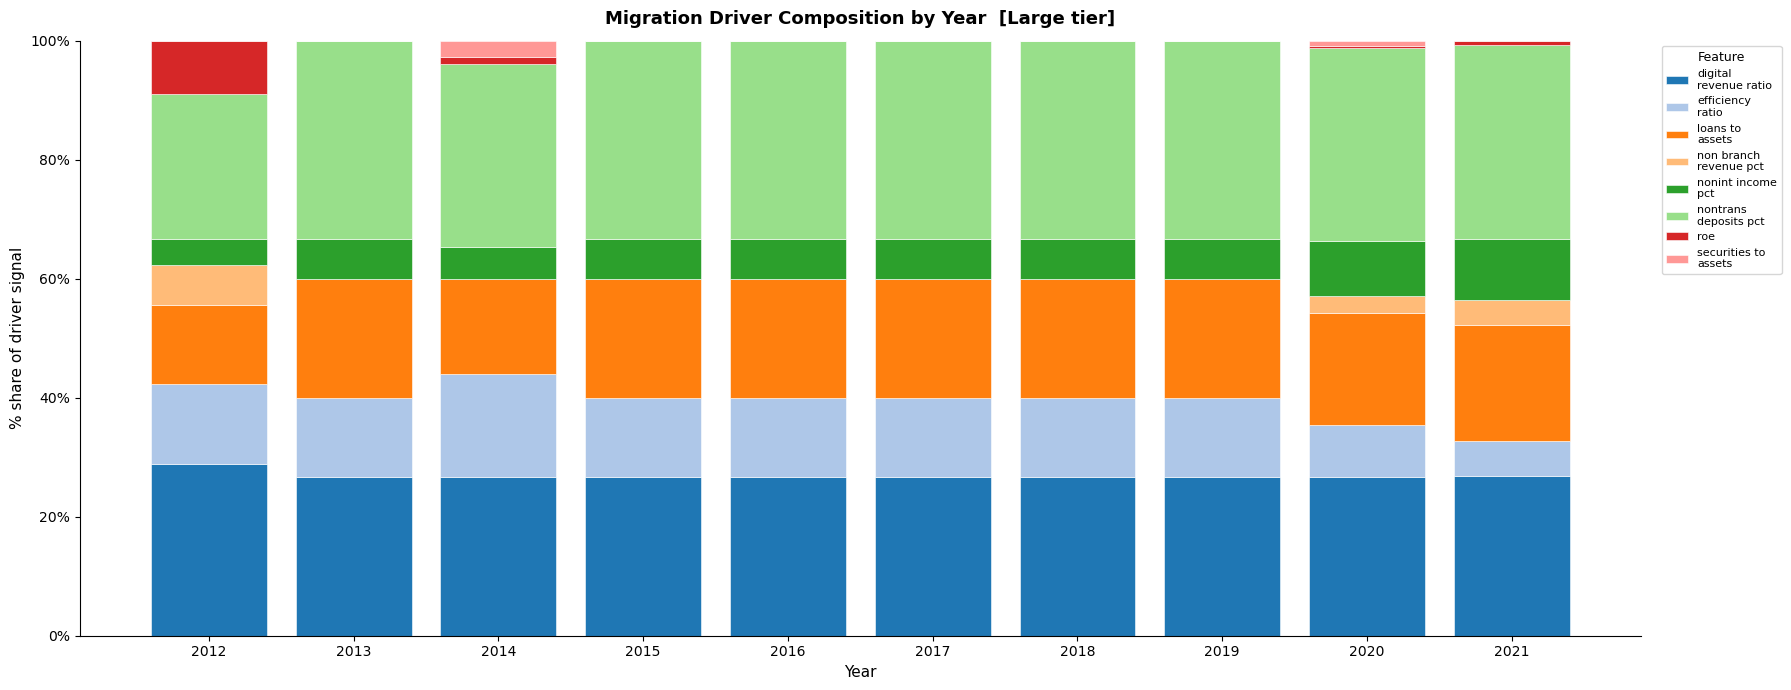

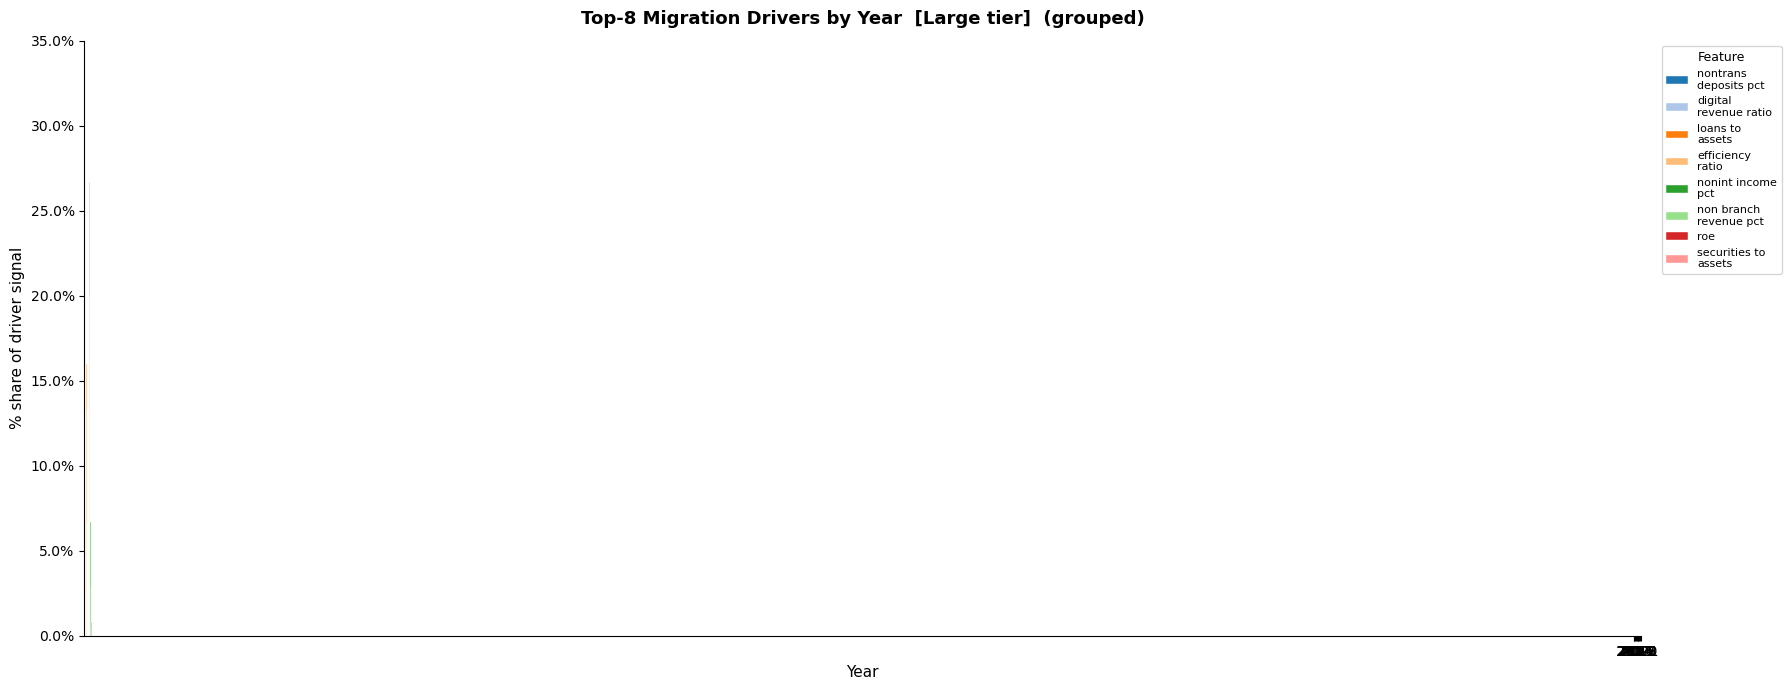

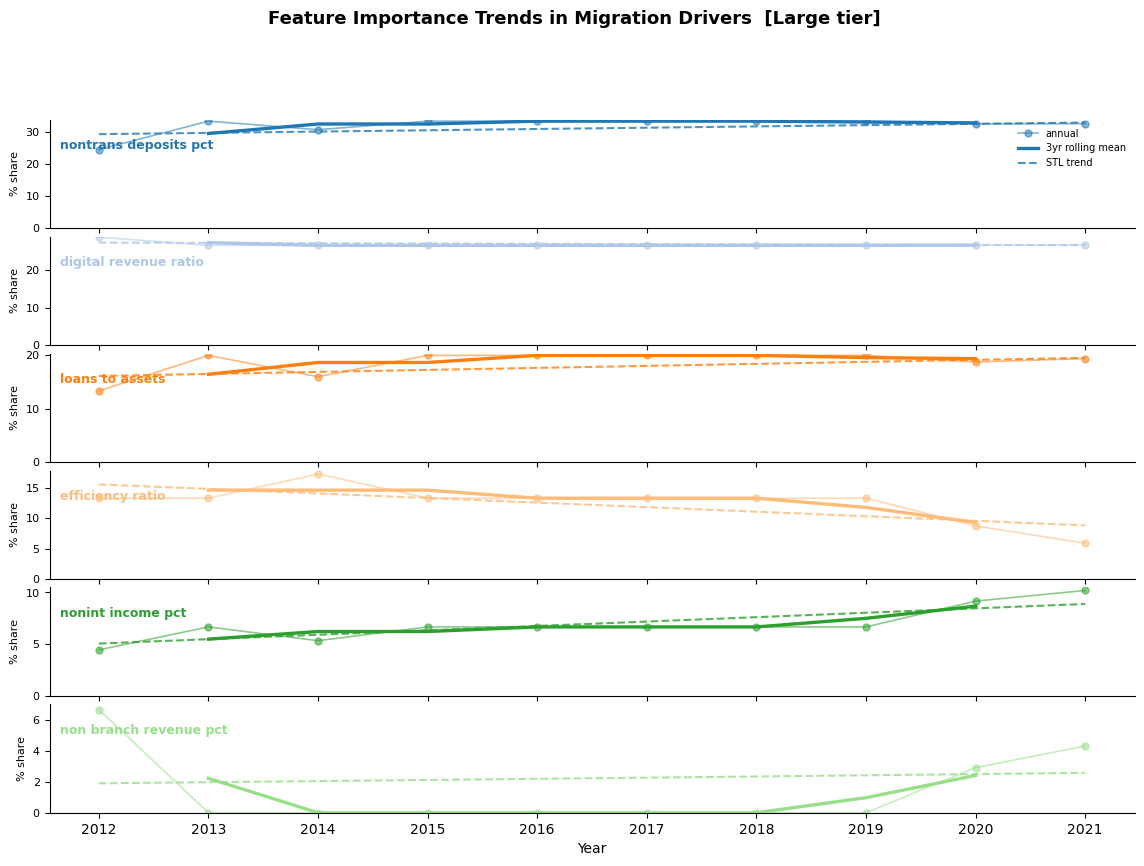

12:35:23 | bank_innovation.driver_analysis | INFO | Driver frequency matrix [Medium]: 10 years × 13 features



════════════════════════════════════════════════════════════════════════
  RANK STABILITY — Large tier  (lower mean_rank = more influential)
════════════════════════════════════════════════════════════════════════
                               mean_rank  rank_std  mean_pct_share  peak_year
nontrans_deposits_pct_change        1.10      0.32           32.02       2013
digital_revenue_ratio_change        1.90      0.32           26.91       2012
loans_to_assets_change              3.15      0.34           18.75       2013
efficiency_ratio_change             4.05      0.60           12.53       2014
nonint_income_pct_change            5.00      0.82            6.91       2021
non_branch_revenue_pct_change       6.80      0.63            1.39       2012
roe_change                          6.90      0.74            1.14       2012
securities_to_assets_change         7.10      0.57            0.35       2014



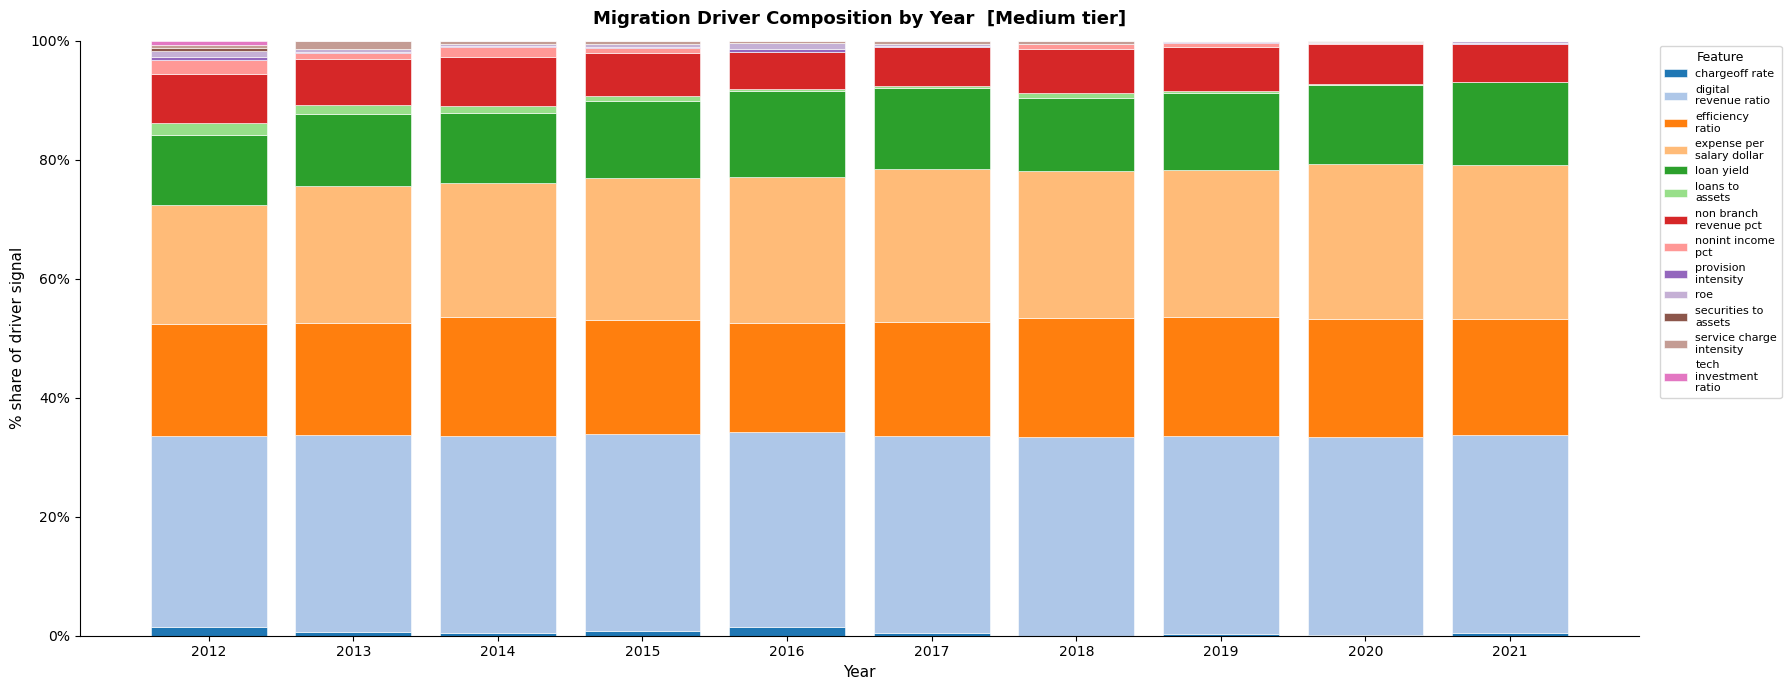

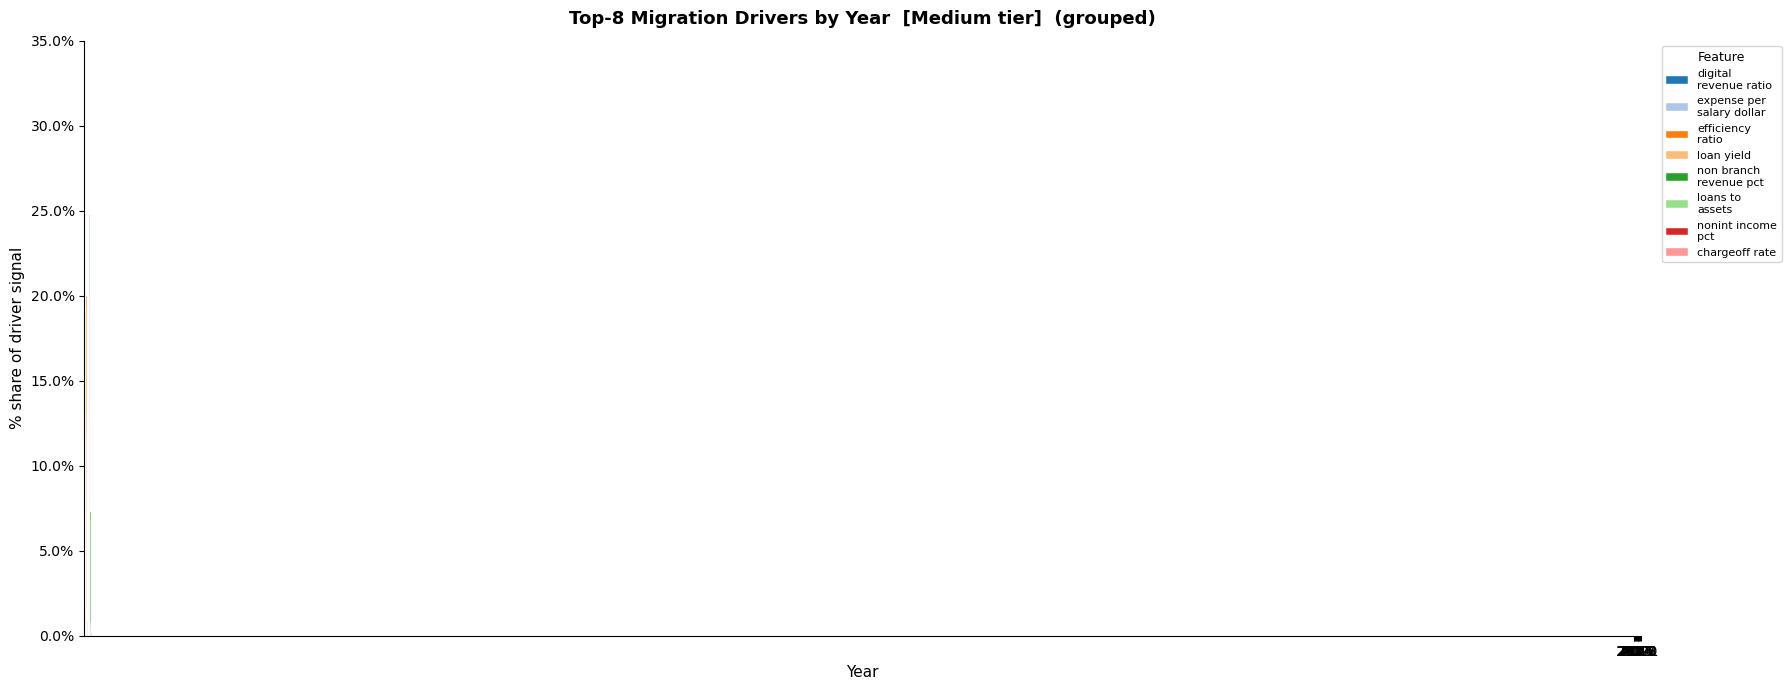

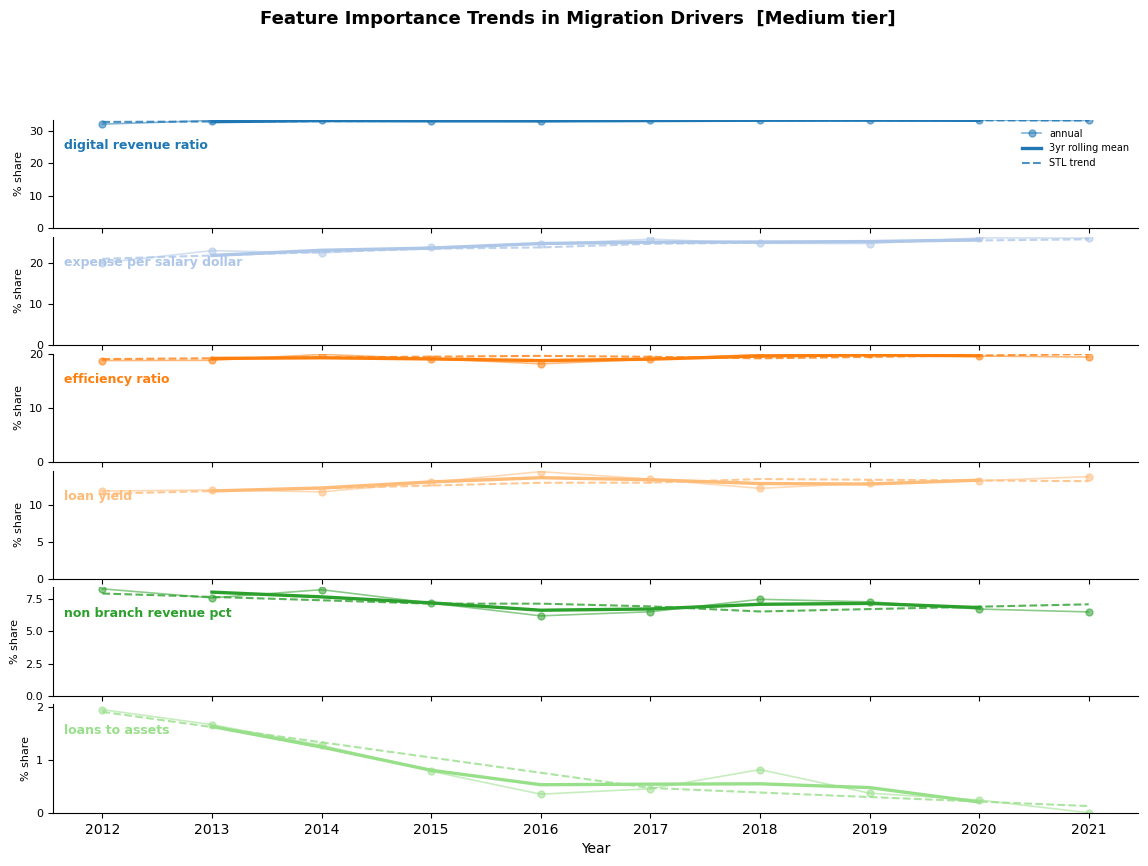

12:35:26 | bank_innovation.driver_analysis | INFO | Driver frequency matrix [Small]: 10 years × 11 features



════════════════════════════════════════════════════════════════════════
  RANK STABILITY — Medium tier  (lower mean_rank = more influential)
════════════════════════════════════════════════════════════════════════
                                  mean_rank  rank_std  mean_pct_share  peak_year
digital_revenue_ratio_change           1.00      0.00           33.05       2018
expense_per_salary_dollar_change       2.00      0.00           24.10       2020
efficiency_ratio_change                3.00      0.00           19.35       2014
loan_yield_change                      4.00      0.00           12.90       2016
non_branch_revenue_pct_change          5.00      0.00            7.20       2012
loans_to_assets_change                 7.60      1.61            0.79       2012
chargeoff_rate_change                  7.90      1.51            0.61       2012
nonint_income_pct_change               8.40      2.51            0.76       2012



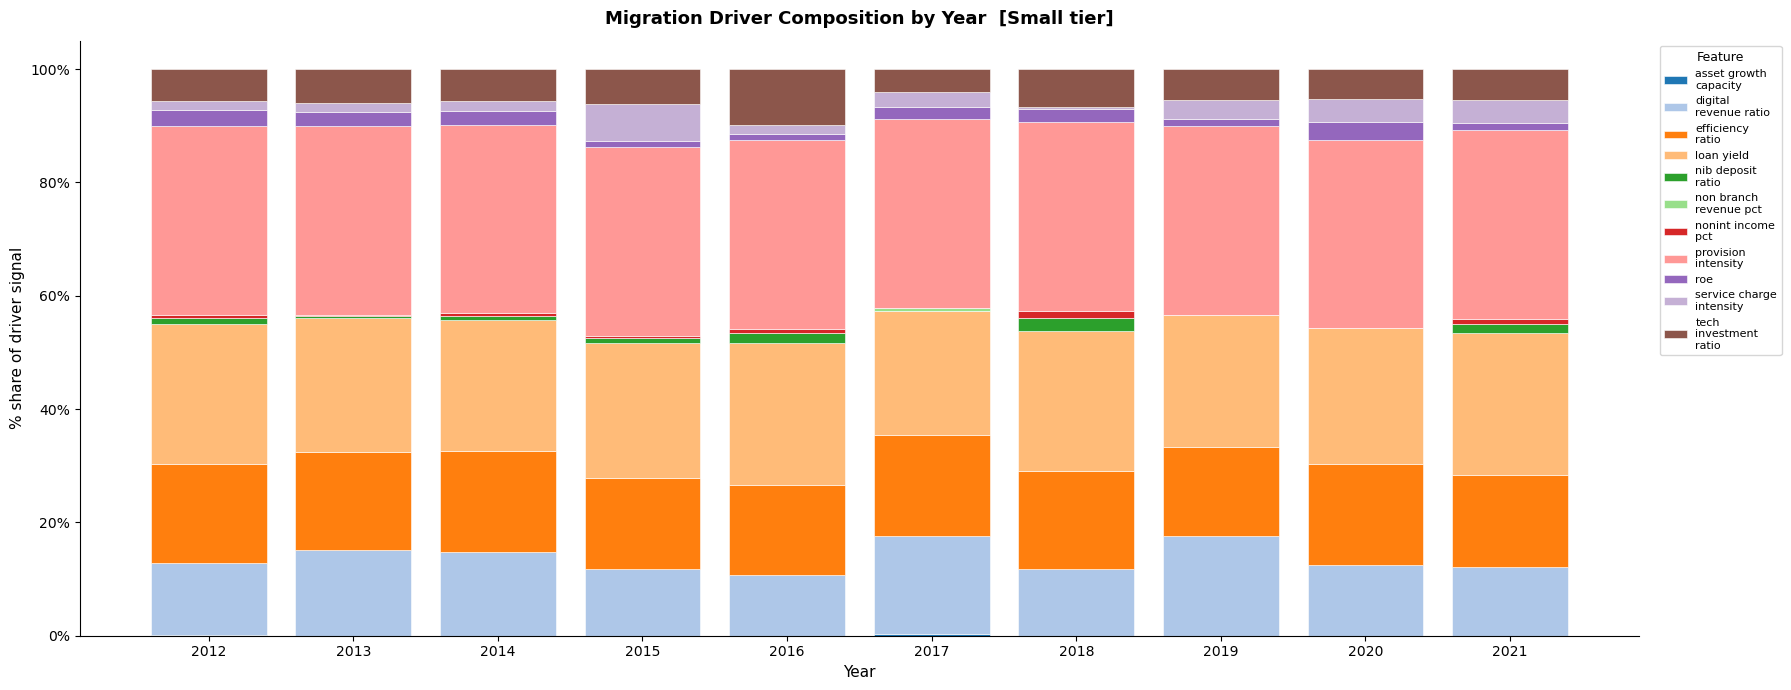

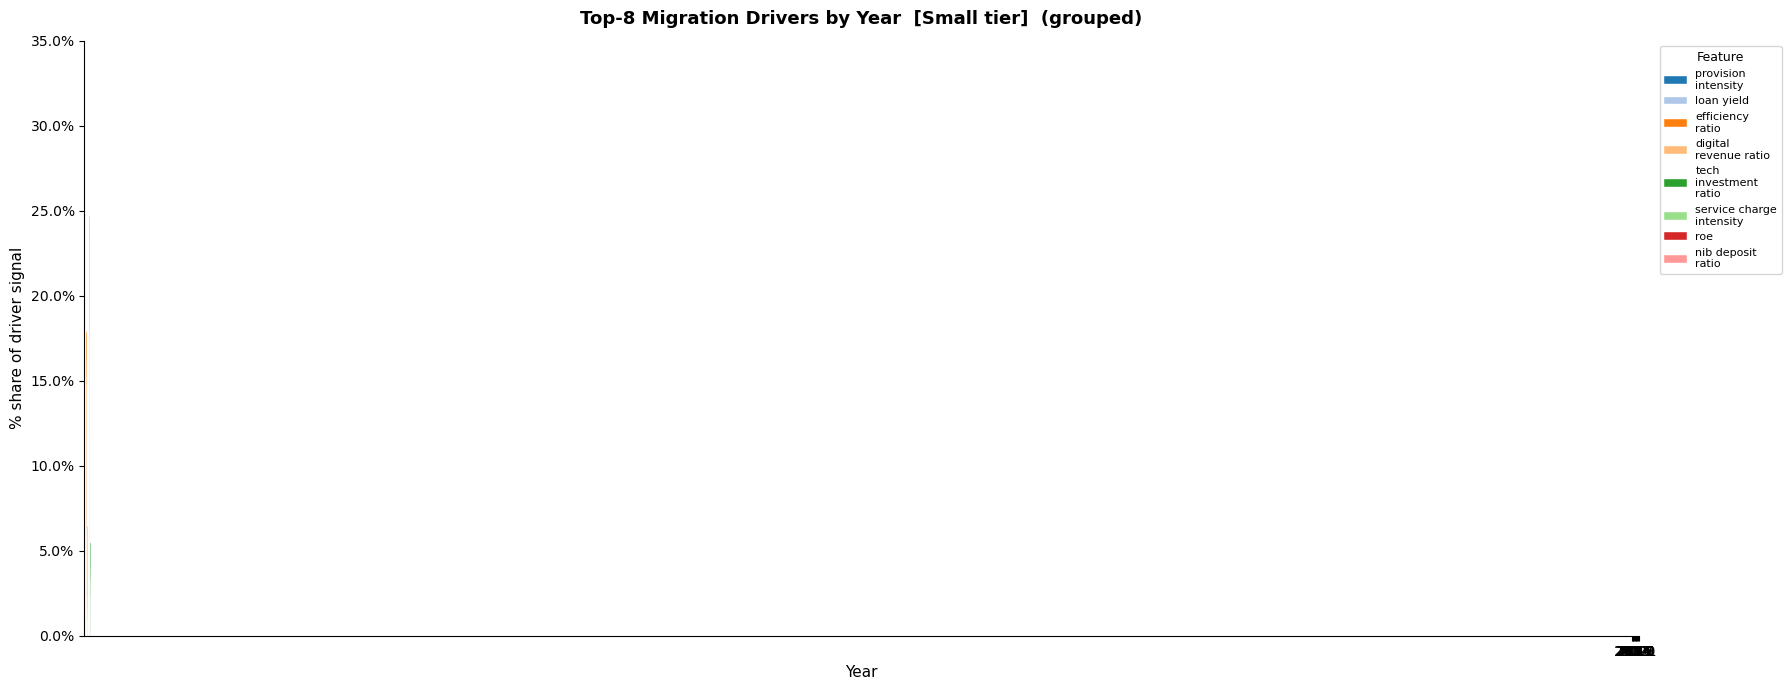

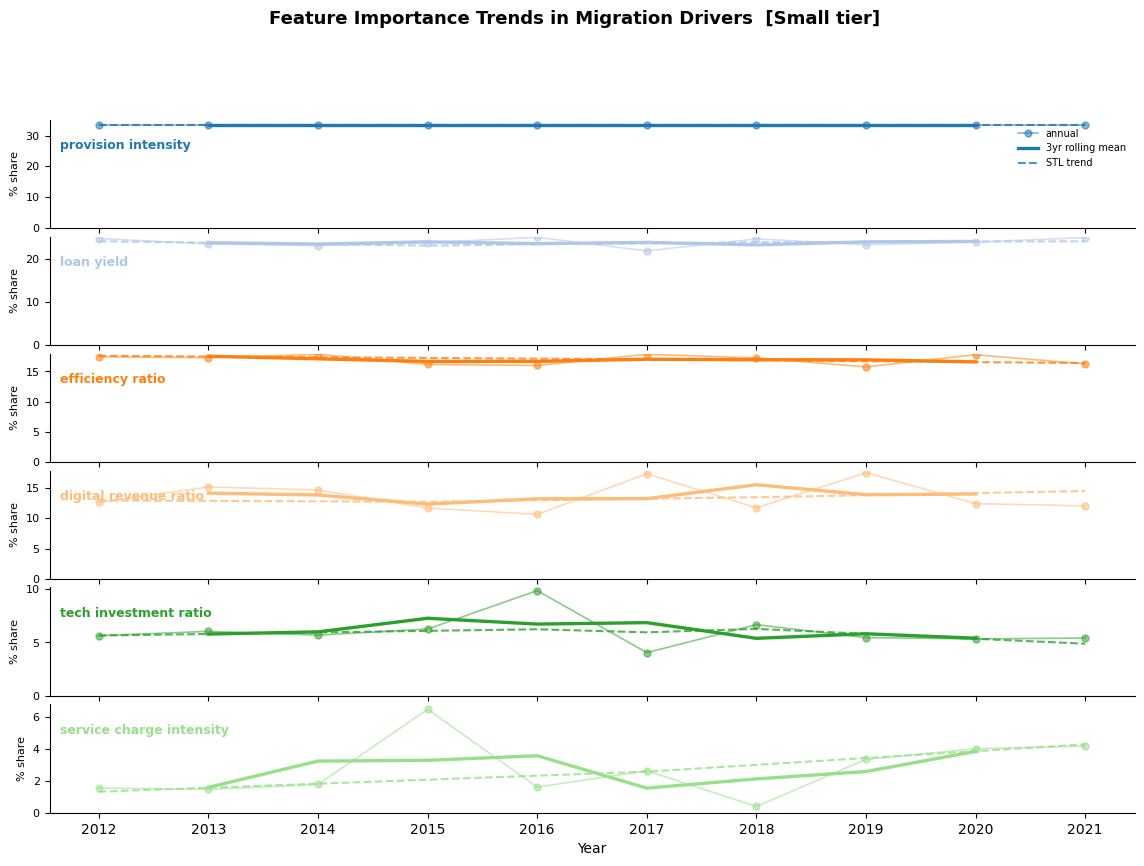

12:35:30 | bank_innovation.driver_analysis | INFO | run_driver_analysis complete.



════════════════════════════════════════════════════════════════════════
  RANK STABILITY — Small tier  (lower mean_rank = more influential)
════════════════════════════════════════════════════════════════════════
                                 mean_rank  rank_std  mean_pct_share  peak_year
provision_intensity_change            1.00      0.00           33.33       2012
loan_yield_change                     2.00      0.00           23.93       2016
efficiency_ratio_change               3.10      0.32           16.96       2017
digital_revenue_ratio_change          3.90      0.32           13.62       2019
tech_investment_ratio_change          5.10      0.32            6.04       2016
service_charge_intensity_change       6.55      1.07            2.73       2015
roe_change                            6.85      0.75            1.99       2020
nib_deposit_ratio_change              8.15      1.33            0.87       2018



In [52]:
results = run_driver_analysis(
    df_changes_optimized,
    migrations,                    # already computed in Cell 7
    tiers=["Large", "Medium", "Small"],
    top_n_drivers=5,
    rolling_window=3,
    save_dir="viz/driver_analysis",
)
 
# Everything is returned in the results dict:
driver_long    = results["driver_long"]    # raw long-form panel
pct_by_tier    = results["pct_by_tier"]    # {"Large": df, ...}
stability      = results["stability"]      # {"Large": df, ...}
figures        = results["figures"]        # list of matplotlib Figure objects
 

In [5]:
from bank_innovation.visualization import create_year_pair_plots

# All year pairs
saved = create_year_pair_plots(df_changes_optimized, output_dir='viz/')

# Or specific year pairs only
saved = create_year_pair_plots(
    df_changes_optimized,
    output_dir='viz/',
    year_pairs=[(2014, 2015), (2019, 2020)]
)